# Seasonal Stage 0 vs Baseline Checker
This notebook compares any two ACORN storage runs and is pre-configured for the Stage 0 seasonal test (`zone_A_seasonal_test_A0`) versus the previous seasonal experiment (`zone_A_seasonal_test_4`).

Use it to verify that the Stage 0 configuration makes the seasonal fleet behave like the base batteries before you start tightening the seasonal parameters.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")
pd.options.display.float_format = lambda x: f"{x:,.2f}"

In [2]:
# --- User configuration -----------------------------------------------------
PROJECT_DIR = Path("/home/fs01/jl2966/acorn-julia2/acorn-julia")
RUN_NAME = "low_RE_mod_elec_iter0"
CLIMATE_SCENARIO = "historical_1980_2019"

# Update these to compare any two runs
BASE_SAVE = "stagel_3month_baseline"
TEST_SAVE = "stagel_3month"

RUNS = {
    "baseline": BASE_SAVE,
    "stage0": TEST_SAVE,
}

BASELINE_LABEL = "baseline"
SEASONAL_LABEL = "stage0"

YEARS = None  # set e.g. [1985] to override automatic discovery

output_root = PROJECT_DIR / "runs" / RUN_NAME / "outputs" / CLIMATE_SCENARIO

def detect_years(save_name: str):
    run_dir = output_root / save_name
    return sorted({int(p.stem.split("_")[1]) for p in run_dir.glob("charge_*.csv")})

if YEARS is None:
    all_years = set()
    for name in RUNS.values():
        all_years |= set(detect_years(name))
    YEARS = sorted(all_years)

print(f"Comparing runs: {RUNS}")
print(f"Comparing years: {YEARS}")


Comparing runs: {'baseline': 'zone_A_seasonal_test_stage0_baseline', 'stage0': 'zone_A_seasonal_test_stage0_2_0seasonal'}
Comparing years: [1985]


In [3]:
# --- Helper functions -------------------------------------------------------

def tidy_storage_df(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    meta_cols = [c for c in ["bus_id", "asset_type", "zone", "is_seasonal"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    return tidy


def tidy_bus_csv(path: Path, value_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    meta_cols = [c for c in ["bus_id", "zone"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    return tidy


def load_storage_csv(run_dir: Path, year: int, value_name: str, split: str | None = None,
                     fallback_combined: bool = True) -> pd.DataFrame:
    # split can be "base" or "seasonal"; will try split files first
    if split in {"base", "seasonal"}:
        split_path = run_dir / f"{value_name}_{split}_{year}.csv"
        if split_path.exists():
            df = pd.read_csv(split_path)
            df = df.copy()
            df["asset_type"] = split
            df["is_seasonal"] = 1 if split == "seasonal" else 0
            return tidy_storage_df(df, value_name)
        if not fallback_combined:
            raise FileNotFoundError(split_path)

    df = pd.read_csv(run_dir / f"{value_name}_{year}.csv")
    debug_path = run_dir / "_storage_debug.csv"
    if debug_path.exists():
        debug = pd.read_csv(debug_path)
        if "is_seasonal" in debug.columns and len(debug) == len(df):
            df = df.copy()
            if "asset_type" not in df.columns:
                df["asset_type"] = "base"
            df.loc[debug["is_seasonal"] == 1, "asset_type"] = "seasonal"
            df["is_seasonal"] = debug["is_seasonal"].values

    if split in {"base", "seasonal"} and "asset_type" in df.columns:
        df = df[df["asset_type"] == split].copy()

    return tidy_storage_df(df, value_name)


def aggregate_timeseries(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    return (df.groupby(["asset_type", "timestamp"])[value_name]
              .sum()
              .reset_index())


def total_timeseries(df: pd.DataFrame, value_name: str) -> pd.Series:
    return df.groupby("timestamp")[value_name].sum()


In [4]:
# --- Load runs --------------------------------------------------------------
run_data = {label: {} for label in RUNS}
run_metrics = {label: {} for label in RUNS}

for label, save_name in RUNS.items():
    run_dir = output_root / save_name
    for year in YEARS:
        charge = load_storage_csv(run_dir, year, "charge")
        discharge = load_storage_csv(run_dir, year, "discharge")
        charge_base = load_storage_csv(run_dir, year, "charge", split="base")
        discharge_base = load_storage_csv(run_dir, year, "discharge", split="base")
        charge_seasonal = load_storage_csv(run_dir, year, "charge", split="seasonal")
        discharge_seasonal = load_storage_csv(run_dir, year, "discharge", split="seasonal")

        load_shed = tidy_bus_csv(run_dir / f"load_shedding_{year}.csv", "load_shedding")
        wind_curt = tidy_bus_csv(run_dir / f"wind_curtailment_{year}.csv", "wind_curtailment")
        solar_curt = tidy_bus_csv(run_dir / f"solar_curtailment_{year}.csv", "solar_curtailment")

        metrics = {
            "load_shed_MWh": load_shed["load_shedding"].sum(),
            "wind_curtailment_MWh": wind_curt["wind_curtailment"].sum(),
            "solar_curtailment_MWh": solar_curt["solar_curtailment"].sum(),
        }

        run_data[label][year] = {
            "charge": charge,
            "discharge": discharge,
            "charge_base": charge_base,
            "discharge_base": discharge_base,
            "charge_seasonal": charge_seasonal,
            "discharge_seasonal": discharge_seasonal,
            "load_shed": load_shed,
            "wind_curt": wind_curt,
            "solar_curt": solar_curt,
            "storage_charge_by_type": aggregate_timeseries(charge, "charge"),
            "storage_discharge_by_type": aggregate_timeseries(discharge, "discharge"),
        }
        run_metrics[label][year] = metrics

print("Loaded runs:")
for label in RUNS:
    print(f"  {label}: years -> {sorted(run_data[label].keys())}")


Loaded runs:
  baseline: years -> [1985]
  stage0: years -> [1985]


In [5]:
# --- Storage throughput comparison -----------------------------------------
for year in YEARS:
    display(Markdown(f"## Year {year} storage throughput"))
    tables = []
    for label in RUNS:
        tbl = run_data[label][year]["storage_summary"].copy()
        tbl = tbl.reset_index().rename(columns={"index": "asset_type"})
        tbl.insert(0, "run", label)
        tbl.insert(1, "year", year)
        tables.append(tbl)
    combined = pd.concat(tables, ignore_index=True)
    display(combined)

    pivot = combined.pivot(index="asset_type", columns="run", values="discharge_MWh")
    pivot = pivot.reindex(["base", "seasonal", "TOTAL"])
    display(Markdown("Discharge delta (stage0 - baseline)"))
    display((pivot["stage0"] - pivot["baseline"]).to_frame("delta_MWh"))

## Year 1985 storage throughput

,run,year,asset_type,charge_MWh,discharge_MWh,net_discharge_MWh,peak_charge_MW,peak_discharge_MW
0,baseline,1985,base,"3,602,316.79","2,705,208.69","-897,108.10","1,176.63","1,176.63"
1,baseline,1985,TOTAL,"3,602,316.79","2,705,208.69","-897,108.10","1,176.63","1,176.63"
2,stage0,1985,base,"2,433,848.25","1,828,857.29","-604,990.97","1,176.63","1,176.63"
3,stage0,1985,seasonal,"2,491,080.31","1,871,781.33","-619,298.98","1,176.63","1,176.63"
4,stage0,1985,TOTAL,"4,924,928.57","3,700,638.62","-1,224,289.95","2,353.25","2,353.25"


Discharge delta (stage0 - baseline)

,delta_MWh
asset_type,
base,"-876,351.40"
seasonal,NaN
TOTAL,"995,429.93"


In [7]:
# --- System metrics (load shed + curtailment) ------------------------------
metrics_rows = []
for year in YEARS:
    for label in RUNS:
        row = {"run": label, "year": year}
        row.update(run_metrics[label][year])
        metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

delta = metrics_df.pivot(index="year", columns="run", values="load_shed_MWh")
if set(delta.columns) >= {"baseline", "stage0"}:
    delta["stage0_minus_baseline"] = delta["stage0"] - delta["baseline"]
    display(Markdown("### Load shedding difference (Stage0 - Baseline)"))
    display(delta)

,run,year,load_shed_MWh,wind_curtailment_MWh,solar_curtailment_MWh
0,baseline,1985,"815,151.13","4,814,090.93","10,520,390.87"
1,stage0,1985,"760,232.85","5,581,511.70","8,871,286.60"


### Load shedding difference (Stage0 - Baseline)

run,baseline,stage0,stage0_minus_baseline
year,,,
1985,"815,151.13","760,232.85","-54,918.28"


In [8]:
# --- Seasonal discharge vs shedding (per year) -----------------------------
import numpy as np

seasonal_label = SEASONAL_LABEL
for year in YEARS:
    discharge_by_type = run_data[seasonal_label][year]["discharge_by_type"]
    seasonal_discharge = (discharge_by_type.query('asset_type == "seasonal"')
                          .groupby("timestamp")["discharge"].sum())
    load_shed = total_timeseries(run_data[seasonal_label][year]["load_shed"], "load_shedding")

    idx = load_shed.index.union(seasonal_discharge.index)
    ls = load_shed.reindex(idx, fill_value=0.0)
    sd = seasonal_discharge.reindex(idx, fill_value=0.0)

    shed_hours = ls > 0
    seasonal_hours = sd > 0
    both_hours = shed_hours & seasonal_hours

    mask = shed_hours | seasonal_hours
    corr = np.corrcoef(ls[mask], sd[mask])[0, 1] if mask.any() else np.nan

    print(f"Year {year} ({seasonal_label})")
    print(f"  seasonal_discharge_MWh: {sd.sum():.1f}")
    print(f"  load_shed_MWh: {ls.sum():.1f}")
    print(f"  hours_with_shed: {int(shed_hours.sum())}")
    print(f"  hours_with_seasonal_discharge: {int(seasonal_hours.sum())}")
    print(f"  hours_with_both: {int(both_hours.sum())}")
    print(f"  corr_shed_vs_seasonal_discharge: {corr:.3f}")

    top = ls.sort_values(ascending=False).head(10)
    print("  Top 10 shedding hours (MW) with seasonal discharge (MW):")
    for ts, shed in top.items():
        print(f"    {ts}: shed {shed:.1f}; seasonal {sd.loc[ts]:.1f}")


Year 1985 (stage0)
  seasonal_discharge_MWh: 1871781.3
  load_shed_MWh: 760232.9
  hours_with_shed: 1238
  hours_with_seasonal_discharge: 2948
  hours_with_both: 747
  corr_shed_vs_seasonal_discharge: 0.073
  Top 10 shedding hours (MW) with seasonal discharge (MW):
    1985-01-21 12:00:00+00:00: shed 5029.0; seasonal 1263.3
    1985-01-20 23:00:00+00:00: shed 4225.2; seasonal 1595.6
    1985-01-10 22:00:00+00:00: shed 4124.5; seasonal 1093.5
    1985-01-21 23:00:00+00:00: shed 3593.3; seasonal 2443.5
    1985-01-22 00:00:00+00:00: shed 3386.3; seasonal 2887.5
    1985-01-21 13:00:00+00:00: shed 3315.6; seasonal 1029.6
    1985-01-21 00:00:00+00:00: shed 2958.8; seasonal 1463.4
    1985-01-21 22:00:00+00:00: shed 2848.2; seasonal 2945.2
    1985-08-16 18:00:00+00:00: shed 2816.8; seasonal 698.8
    1985-07-21 20:00:00+00:00: shed 2751.1; seasonal 1266.6


In [9]:
# --- Zonal shedding deltas (seasonal vs baseline) --------------------------
for year in YEARS:
    base_ls = run_data[BASELINE_LABEL][year]["load_shed"]
    sea_ls = run_data[SEASONAL_LABEL][year]["load_shed"]

    base_zone = base_ls.groupby("zone")["load_shedding"].sum()
    sea_zone = sea_ls.groupby("zone")["load_shedding"].sum()

    zones = sorted(set(base_zone.index) | set(sea_zone.index))
    rows = []
    for z in zones:
        b = float(base_zone.get(z, 0.0))
        s = float(sea_zone.get(z, 0.0))
        rows.append((z, b, s, s - b))

    df = pd.DataFrame(rows, columns=["zone", "baseline_MWh", "seasonal_MWh", "delta_MWh"])
    df = df.sort_values("delta_MWh")
    display(Markdown(f"### Year {year} zonal shedding (seasonal - baseline)"))
    display(df)


### Year 1985 zonal shedding (seasonal - baseline)

,zone,baseline_MWh,seasonal_MWh,delta_MWh
1,B,"96,318.87","32,261.19","-64,057.68"
10,K,"671,407.20","633,134.46","-38,272.74"
9,J,"23,937.67",0.00,"-23,937.67"
6,G,"23,487.39","22,389.57","-1,097.82"
3,D,0.00,164.76,164.76
8,I,0.00,"1,187.32","1,187.32"
4,E,0.00,"1,192.93","1,192.93"
5,F,0.00,"1,280.20","1,280.20"
2,C,0.00,"3,835.62","3,835.62"
7,H,0.00,"4,026.22","4,026.22"


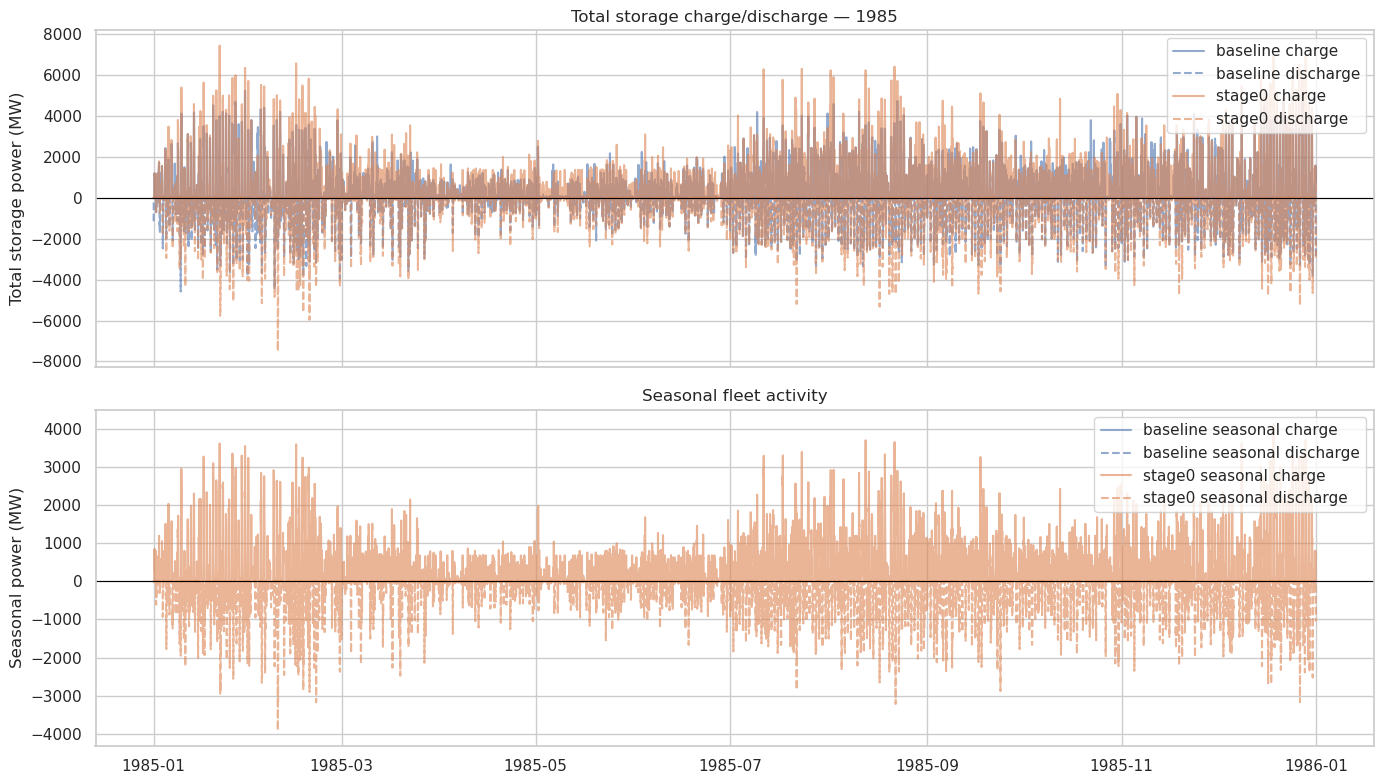

In [10]:
# --- Time-series plots -----------------------------------------------------
for year in YEARS:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    for label, color in zip(RUNS, ["C0", "C1"]):
        total_charge = (run_data[label][year]["charge_by_type"]
                        .groupby("timestamp")["charge"].sum())
        total_discharge = (run_data[label][year]["discharge_by_type"]
                           .groupby("timestamp")["discharge"].sum())
        axes[0].plot(total_charge.index, total_charge.values,
                    label=f"{label} charge", color=color, alpha=0.6)
        axes[0].plot(total_discharge.index, -total_discharge.values,
                    label=f"{label} discharge", color=color, linestyle="--", alpha=0.6)

        seasonal_charge = (run_data[label][year]["charge_by_type"]
                           .query('asset_type == "seasonal"')
                           .groupby("timestamp")["charge"].sum())
        seasonal_discharge = (run_data[label][year]["discharge_by_type"]
                              .query('asset_type == "seasonal"')
                              .groupby("timestamp")["discharge"].sum())
        axes[1].plot(seasonal_charge.index, seasonal_charge.values,
                    label=f"{label} seasonal charge", color=color, alpha=0.6)
        axes[1].plot(seasonal_discharge.index, -seasonal_discharge.values,
                    label=f"{label} seasonal discharge", color=color, linestyle="--", alpha=0.6)

    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_ylabel("Total storage power (MW)")
    axes[0].set_title(f"Total storage charge/discharge — {year}")
    axes[0].legend(loc="upper right")

    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_ylabel("Seasonal power (MW)")
    axes[1].set_title("Seasonal fleet activity")
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()


### Next steps
- If Stage 0 seasonal charge/discharge lines align with the baseline `base` fleet, you have successfully mimicked the original batteries.
- Re-run the notebook after toggling `--seasonal_rate_caps_on` or changing SOC floors to see how utilization, load shedding, and curtailment respond.
- Extend the metrics block with additional diagnostics (e.g., monthly SOC swing) as you explore multi-month behavior.

In [ ]:
# --- Notes-driven diagnostics ---------------------------------------------
from dataclasses import dataclass

@dataclass
class EventStats:
    start: pd.Timestamp
    end: pd.Timestamp
    hours: int
    total: float


def event_stats(series: pd.Series, threshold: float = 1e-6) -> pd.DataFrame:
    s = series.fillna(0.0)
    events = []
    in_event = False
    start = None
    total = 0.0
    hours = 0
    for ts, val in s.items():
        if val > threshold:
            if not in_event:
                in_event = True
                start = ts
                total = 0.0
                hours = 0
            total += float(val)
            hours += 1
            end = ts
        else:
            if in_event:
                events.append(EventStats(start, end, hours, total))
                in_event = False
    if in_event:
        events.append(EventStats(start, end, hours, total))

    if not events:
        return pd.DataFrame(columns=["start", "end", "hours", "total_MWh"])
    return pd.DataFrame([{
        "start": e.start,
        "end": e.end,
        "hours": e.hours,
        "total_MWh": e.total,
    } for e in events]).sort_values("hours", ascending=False)


def season_label(ts: pd.Timestamp) -> str:
    m = ts.month
    if m in (12, 1, 2):
        return "DJF"
    if m in (3, 4, 5):
        return "MAM"
    if m in (6, 7, 8):
        return "JJA"
    return "SON"


def seasonal_usage_metrics(label: str, year: int) -> dict:
    seasonal_discharge = total_timeseries(run_data[label][year]["discharge_seasonal"], "discharge")
    base_discharge = total_timeseries(run_data[label][year]["discharge_base"], "discharge")
    load_shed = total_timeseries(run_data[label][year]["load_shed"], "load_shedding")

    season = seasonal_discharge.index.map(season_label)
    by_season = seasonal_discharge.groupby(season).sum().reindex(["DJF", "MAM", "JJA", "SON"]).fillna(0.0)

    seasonal_events = event_stats(seasonal_discharge)
    drought_events = event_stats(load_shed, threshold=0.0)

    # Usage during shortage hours
    shed_hours = load_shed > 0
    base_during_shed = base_discharge.reindex(load_shed.index, fill_value=0.0)[shed_hours].sum()
    seasonal_during_shed = seasonal_discharge.reindex(load_shed.index, fill_value=0.0)[shed_hours].sum()

    return {
        "seasonal_discharge_MWh": seasonal_discharge.sum(),
        "seasonal_events": seasonal_events,
        "drought_events": drought_events,
        "by_season": by_season,
        "base_during_shed_MWh": base_during_shed,
        "seasonal_during_shed_MWh": seasonal_during_shed,
    }


In [ ]:
# --- Notes-driven diagnostics (reports) -----------------------------------
for year in YEARS:
    print(f"
=== Year {year}")
    base_label = BASELINE_LABEL
    test_label = SEASONAL_LABEL

    base_ls = total_timeseries(run_data[base_label][year]["load_shed"], "load_shedding")
    test_ls = total_timeseries(run_data[test_label][year]["load_shed"], "load_shedding")
    seasonal_discharge = total_timeseries(run_data[test_label][year]["discharge_seasonal"], "discharge")

    # Load shedding reduction (baseline - test)
    ls_delta = base_ls.reindex(test_ls.index, fill_value=0.0) - test_ls.reindex(base_ls.index, fill_value=0.0)
    print(f"Load shed reduction (MWh): {ls_delta.sum():.1f}")

    # Weeks with no seasonal use + little/no load shed reduction
    weekly = pd.DataFrame({
        "seasonal_discharge_MWh": seasonal_discharge.resample("W").sum(),
        "load_shed_reduction_MWh": ls_delta.resample("W").sum(),
    }).fillna(0.0)
    unused = weekly[(weekly["seasonal_discharge_MWh"] < 1e-3)]
    print(f"Weeks with ~0 seasonal discharge: {len(unused)}")
    if len(unused):
        display(unused.head(10))

    # Seasonal usage frequency + drought events
    metrics = seasonal_usage_metrics(test_label, year)
    print("Seasonal discharge by season (MWh):")
    display(metrics["by_season"].to_frame("seasonal_discharge_MWh"))

    if not metrics["seasonal_events"].empty:
        print("Top seasonal discharge events (hours, MWh):")
        display(metrics["seasonal_events"].head(5))
    else:
        print("No seasonal discharge events found.")

    if not metrics["drought_events"].empty:
        print("Top load shedding (drought) events (hours, MWh):")
        display(metrics["drought_events"].head(5))
    else:
        print("No load shedding events found.")

    print(f"Discharge during shedding (MWh) — base: {metrics['base_during_shed_MWh']:.1f}, seasonal: {metrics['seasonal_during_shed_MWh']:.1f}")


In [ ]:
# --- Seasonal usage diagnostics & visualization -----------------------------
import numpy as np

for year in YEARS:
    print(f"
=== Seasonal usage diagnostics: {year}")
    label = SEASONAL_LABEL
    run_dir = output_root / RUNS[label]

    # Time series
    base_charge = total_timeseries(run_data[label][year]["charge_base"], "charge")
    base_discharge = total_timeseries(run_data[label][year]["discharge_base"], "discharge")
    seasonal_charge = total_timeseries(run_data[label][year]["charge_seasonal"], "charge")
    seasonal_discharge = total_timeseries(run_data[label][year]["discharge_seasonal"], "discharge")
    load_shed = total_timeseries(run_data[label][year]["load_shed"], "load_shedding")

    # Print usage summary
    print(f"Base discharge MWh: {base_discharge.sum():.1f}")
    print(f"Seasonal discharge MWh: {seasonal_discharge.sum():.1f}")
    print(f"Seasonal discharge hours (>0): {int((seasonal_discharge > 0).sum())}")
    print(f"Load shedding hours (>0): {int((load_shed > 0).sum())}")

    # Simple plot: base vs seasonal vs load shedding
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    axes[0].plot(base_charge.index, base_charge.values, label="base charge", alpha=0.6)
    axes[0].plot(base_discharge.index, -base_discharge.values, label="base discharge", alpha=0.6)
    axes[0].plot(seasonal_charge.index, seasonal_charge.values, label="seasonal charge", alpha=0.6)
    axes[0].plot(seasonal_discharge.index, -seasonal_discharge.values, label="seasonal discharge", alpha=0.6)
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_ylabel("MW")
    axes[0].set_title("Storage fleet activity")
    axes[0].legend(loc="upper right")

    axes[1].plot(load_shed.index, load_shed.values, color="C3", label="load shedding")
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_ylabel("MW")
    axes[1].set_title("Load shedding")
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()


In [ ]:
# --- Why seasonal not used? (quick checks) -----------------------------------
# Uses _storage_debug.csv to inspect seasonal capacity and rate caps
for year in YEARS:
    label = SEASONAL_LABEL
    run_dir = output_root / RUNS[label]
    debug_path = run_dir / "_storage_debug.csv"
    if not debug_path.exists():
        print(f"No _storage_debug.csv for {run_dir}")
        continue

    debug = pd.read_csv(debug_path)
    if "is_seasonal" not in debug.columns:
        print("No is_seasonal column in _storage_debug.csv")
        continue

    seasonal = debug[debug["is_seasonal"] == 1].copy()
    if seasonal.empty:
        print("No seasonal rows in _storage_debug.csv")
        continue

    # Estimate per-hour max discharge MW from rate caps if present
    if "max_discharge_rate_frac" in seasonal.columns:
        max_discharge_MW = (seasonal["max_discharge_rate_frac"] * seasonal["storage_capacity_mwh"]).sum()
    else:
        max_discharge_MW = np.nan

    print(f"Seasonal rows: {len(seasonal)}")
    print(f"Total seasonal energy capacity (MWh): {seasonal['storage_capacity_mwh'].sum():.1f}")
    print(f"Total seasonal charge capacity (MW): {seasonal['charge_capacity_MW'].sum():.1f}")
    print(f"Estimated max seasonal discharge MW (rate-cap): {max_discharge_MW:.2f}")

    # Compare with max load shedding to see if seasonal could help
    load_shed = total_timeseries(run_data[label][year]["load_shed"], "load_shedding")
    print(f"Peak load shedding MW: {load_shed.max():.2f}")
